/tmp/ipykernel_3363739/3829813303.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.90,1])


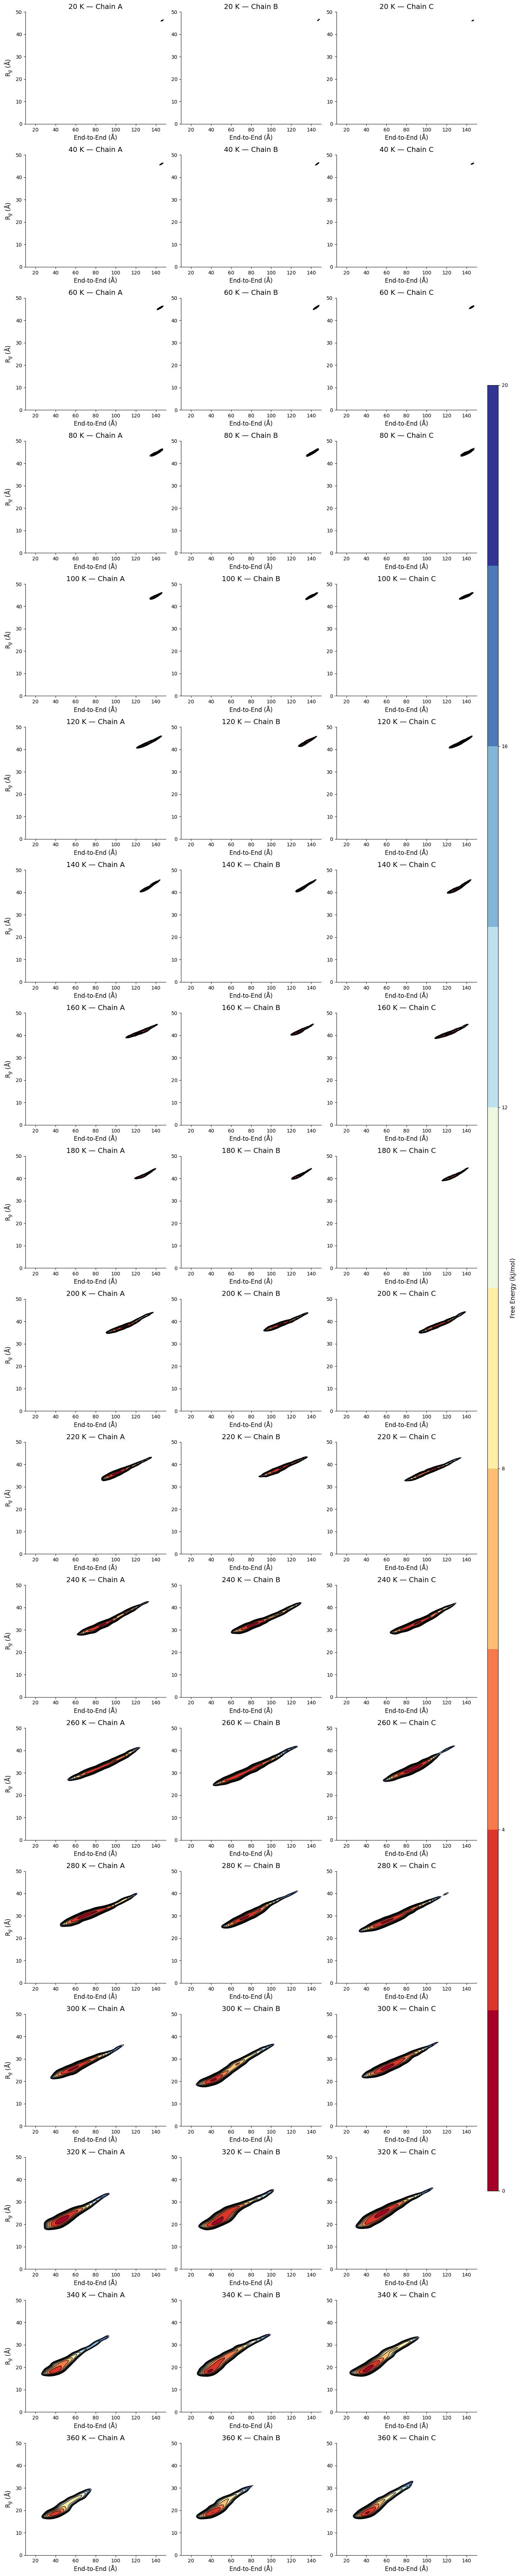

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import math

# ─── Constants ────────────────────────────────────────────────────────────────
kB    = 0.008314    # kJ/(mol·K)
nbins = (75, 75)
sigma = 2.0         # smoothing kernel width
max_F = 20.0        # kJ/mol cutoff

# ─── Load your frame‑wise mean data ───────────────────────────────────────────
df_rg  = pd.read_csv('POG12_replicas_framewise_meanRg.csv')
df_e2e = pd.read_csv('POG12_replicas_framewise_meanE2E.csv')

# ─── Merge on Temperature, Chain, Frame ───────────────────────────────────────
df = pd.merge(
    df_rg,
    df_e2e,
    on=['Temperature (K)', 'Chain', 'Frame']
)

# ─── Prepare plot grid ────────────────────────────────────────────────────────
temps  = sorted(df['Temperature (K)'].unique())
chains = ['A','B','C']
n_rows = len(temps)
n_cols = len(chains)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows),
                         sharex=False, sharey=False)

# ─── Loop over temperatures and chains ────────────────────────────────────────
for i, temp in enumerate(temps):
    df_temp = df[df['Temperature (K)'] == temp]
    for j, chain in enumerate(chains):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        sub = df_temp[df_temp['Chain'] == chain]
        x = sub['Mean E2E (Å)'].values
        y = sub['Mean Rg (Å)'].values

        # 2D histogram → probability density
        x0, x1 = x.min() - 0.5, x.max() + 0.5
        y0, y1 = y.min() - 0.5, y.max() + 0.5
        hist, xe, ye = np.histogram2d(
            x, y,
            bins=nbins,
            range=[[x0, x1], [y0, y1]],
            density=True
        )

        # Free energy surface (Boltzmann inversion)
        F     = -kB * temp * np.log(hist + 1e-12)
        F    -= np.nanmin(F)
        F_s   = gaussian_filter(F, sigma=(sigma, sigma))
        mask  = (hist < 1e-8) | (F_s > max_F)
        Fm    = np.ma.array(F_s, mask=mask)

        # Contours
        levels = np.arange(0, max_F+2, 2)
        cmap   = plt.get_cmap('RdYlBu', len(levels)-1)

        cf = ax.contourf(
            xe[:-1], ye[:-1], Fm.T,
            levels=levels, cmap=cmap
        )
        ax.contour(
            xe[:-1], ye[:-1], F_s.T,
            levels=levels, colors='black', linewidths=1
        )

        # Styling
        ax.set_title(f'{temp} K — Chain {chain}', fontsize=14)
        ax.set_xlabel('End‑to‑End (Å)', fontsize=12)
        ax.set_ylabel('R$_g$ (Å)', fontsize=12) if j == 0 else None
        ax.set_ylim(0, 50)
        ax.set_xlim(10, 150)
        ax.tick_params(labelsize=10)
        for side in ['top', 'right']:
            ax.spines[side].set_visible(False)

# ─── Add shared colorbar ──────────────────────────────────────────────────────
fig.subplots_adjust(right=0.90, hspace=0.4, wspace=0.3)
cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('Free Energy (kJ/mol)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0,0,0.90,1])
plt.show()


/tmp/ipykernel_3363739/1583407487.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


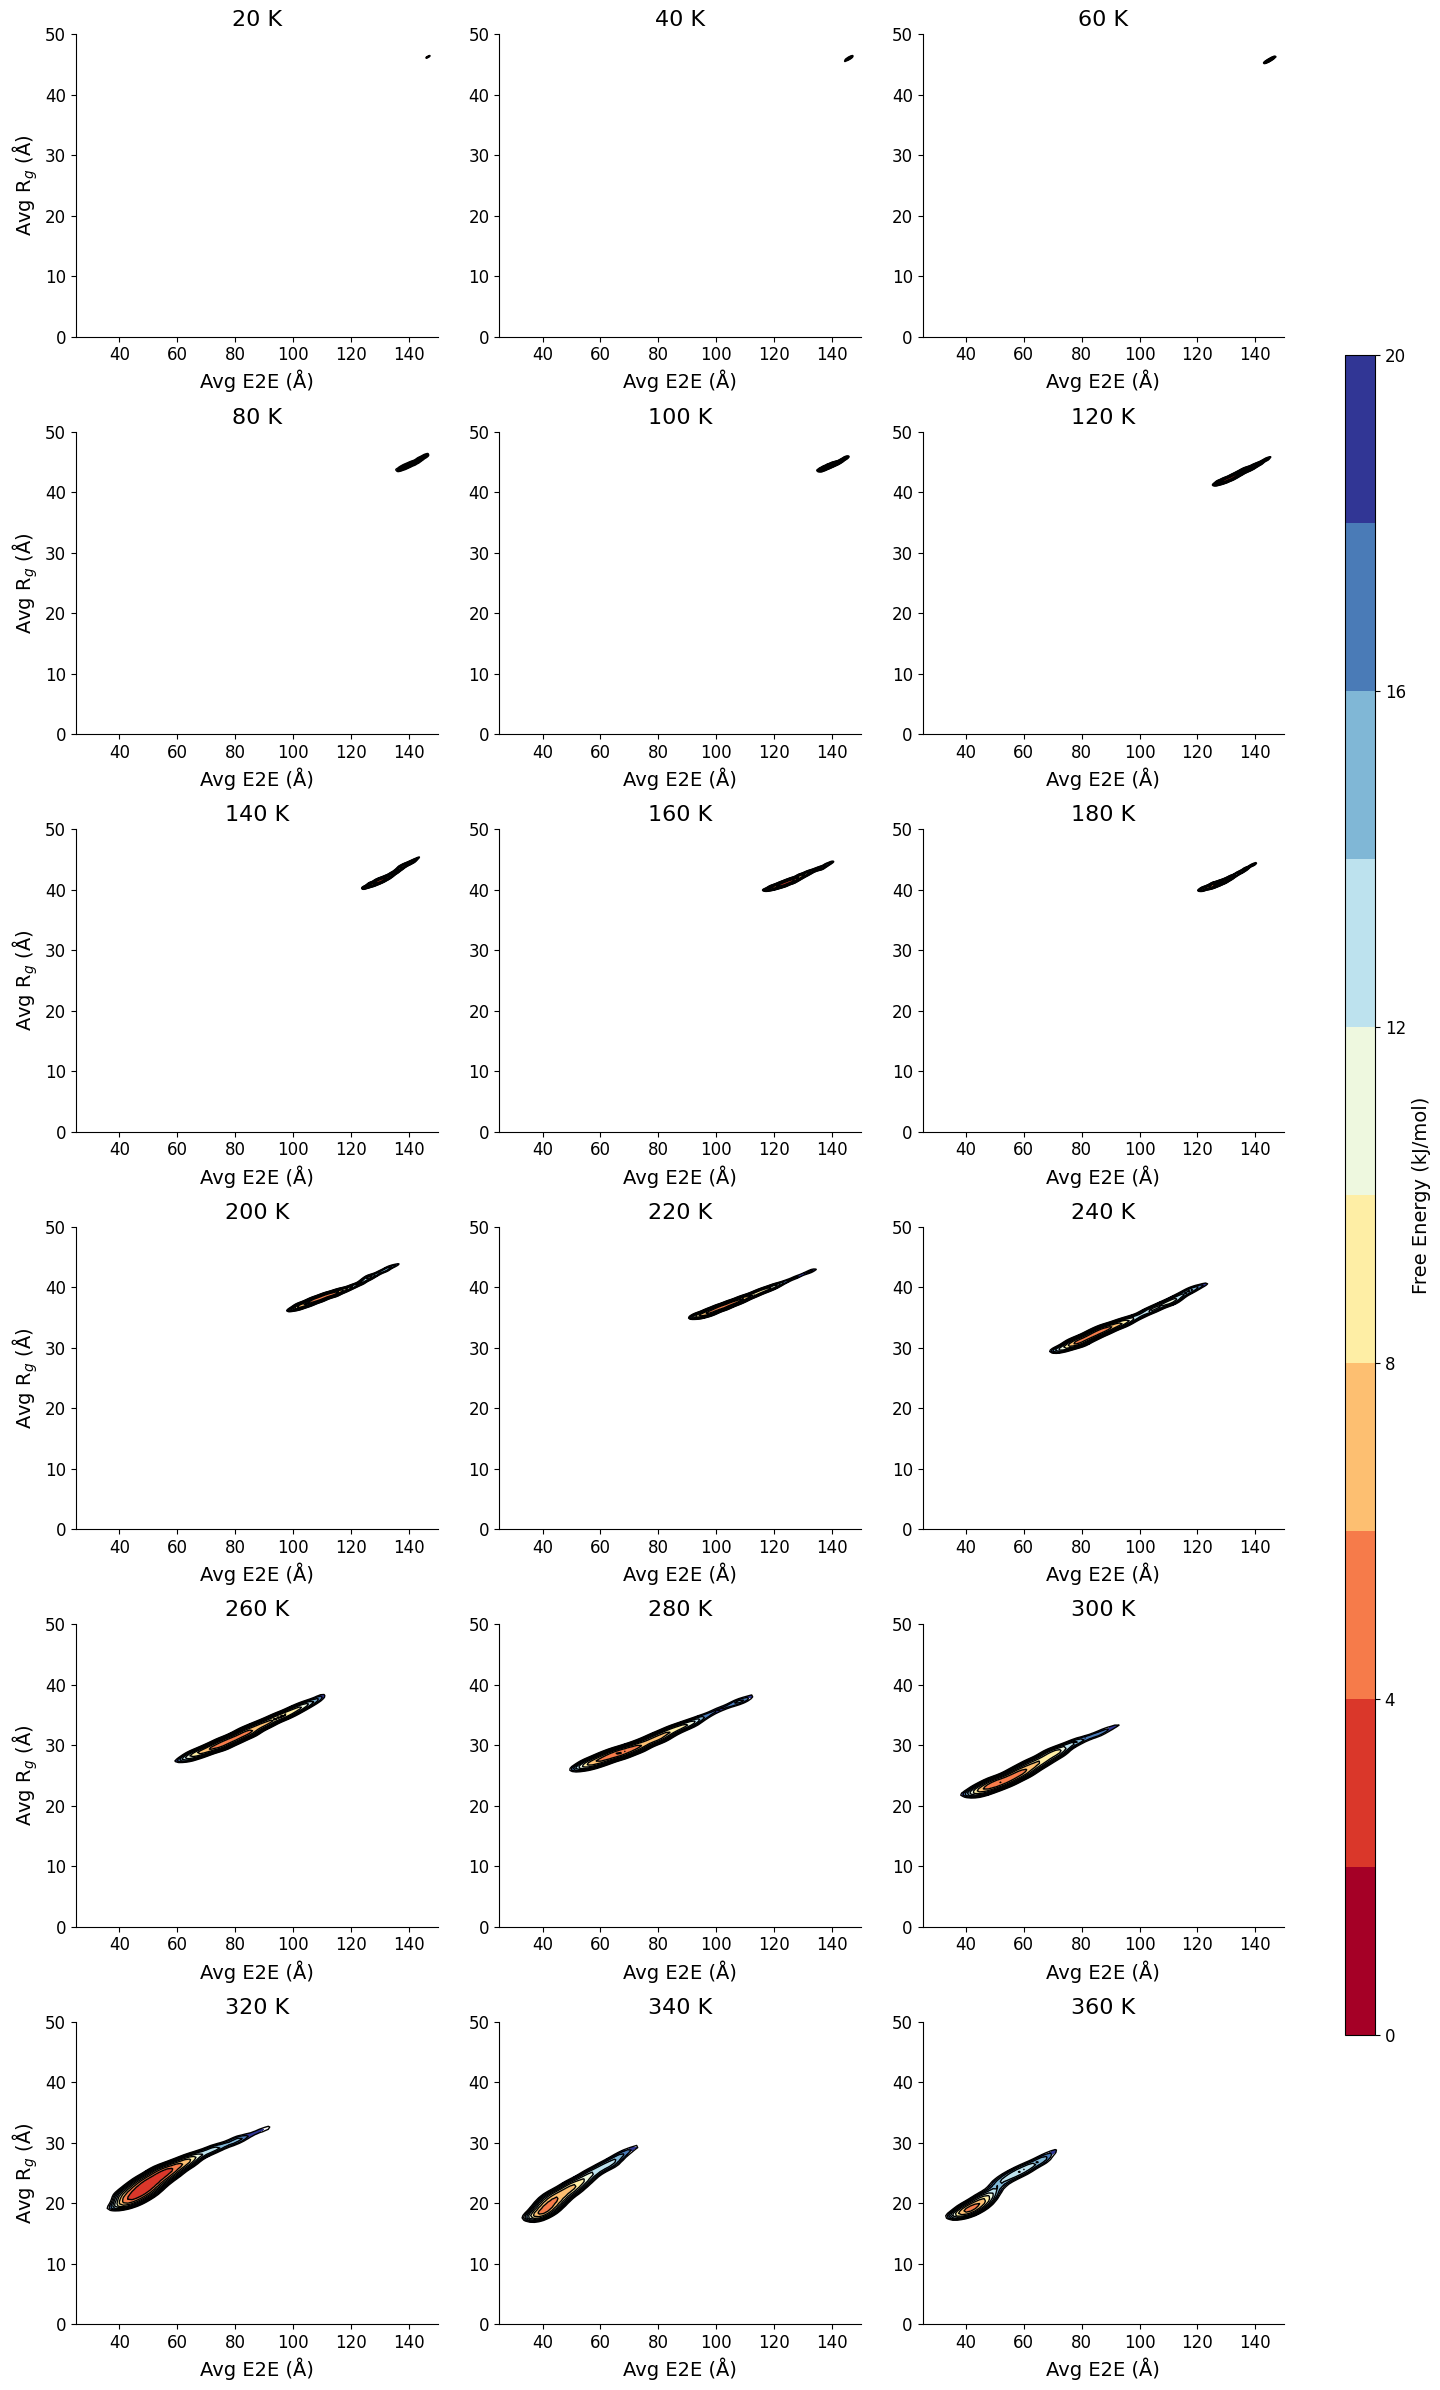

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import math

# ─── Constants ────────────────────────────────────────────────────────────────
kB    = 0.008314    # kJ/(mol·K)
nbins = (75, 75)
sigma = 2.0         # smoothing σ
max_F = 20.0        # kJ/mol cutoff

# ─── 1) Load your frame‑wise mean CSVs ────────────────────────────────────────
df_rg  = pd.read_csv('POG12_replicas_framewise_meanRg.csv')     # has 'Mean Rg (Å)'
df_e2e = pd.read_csv('POG12_replicas_framewise_meanE2E.csv')    # has 'Mean E2E (Å)'

# ─── 2) Merge on Temperature, Chain, Frame ───────────────────────────────────
df = pd.merge(
    df_rg,
    df_e2e,
    on=['Temperature (K)', 'Chain', 'Frame']
)

# ─── 3) Compute per‑frame average across chains for each temperature ─────────
df_avg = (
    df
      .groupby(['Temperature (K)', 'Frame'], as_index=False)
      [['Mean E2E (Å)', 'Mean Rg (Å)']]
      .mean()
      .rename(columns={
          'Mean E2E (Å)': 'E2E_Å',
          'Mean Rg (Å)' : 'Rg_Å'
      })
)

# ─── 4) Prepare for plotting: one panel per temperature ──────────────────────
temps   = sorted(df_avg['Temperature (K)'].unique())
n_temps = len(temps)
n_cols  = 3
n_rows  = math.ceil(n_temps / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4 * n_rows),
                         squeeze=False)

for idx, temp in enumerate(temps):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    sub = df_avg[df_avg['Temperature (K)'] == temp]
    x   = sub['E2E_Å'].values
    y   = sub['Rg_Å'].values

    # 5) Build 2D histogram → probability density
    x0, x1 = x.min() - 0.5, x.max() + 0.5
    y0, y1 = y.min() - 0.5, y.max() + 0.5
    hist, xe, ye = np.histogram2d(
        x, y,
        bins=nbins,
        range=[[x0, x1], [y0, y1]],
        density=True
    )

    # 6) Convert to free energy at this temperature
    F    = -kB * temp * np.log(hist + 1e-12)
    F   -= np.nanmin(F)
    F_s  = gaussian_filter(F, sigma=(sigma, sigma))
    mask = (hist < 1e-8) | (F_s > max_F)
    Fm   = np.ma.array(F_s, mask=mask)

    # 7) Contour levels and colormap
    levels = np.arange(0, max_F + 2, 2)
    cmap   = plt.get_cmap('RdYlBu', len(levels) - 1)

    # 8) Plot filled contours and outlines
    cf = ax.contourf(
        xe[:-1], ye[:-1], Fm.T,
        levels=levels, cmap=cmap
    )
    cs = ax.contour(
        xe[:-1], ye[:-1], F_s.T,
        levels=levels, colors='black', linewidths=1
    )

    # 9) Styling
    ax.set_title(f'{temp} K', fontsize=16)
    ax.set_xlabel('Avg E2E (Å)', fontsize=14)
    ax.set_xlim(25, 150)
    ax.set_ylim(0, 50)
    if col == 0:
        ax.set_ylabel('Avg R$_g$ (Å)', fontsize=14)
    ax.tick_params(labelsize=12)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)

# ─── 10) Hide unused subplots ────────────────────────────────────────────────
total_plots = n_rows * n_cols
for unused in range(len(temps), total_plots):
    r, c = divmod(unused, n_cols)
    axes[r][c].axis('off')

# ─── 11) Shared colorbar on the right ────────────────────────────────────────
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.set_label('Free Energy (kJ/mol)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


/tmp/ipykernel_3363739/603496022.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


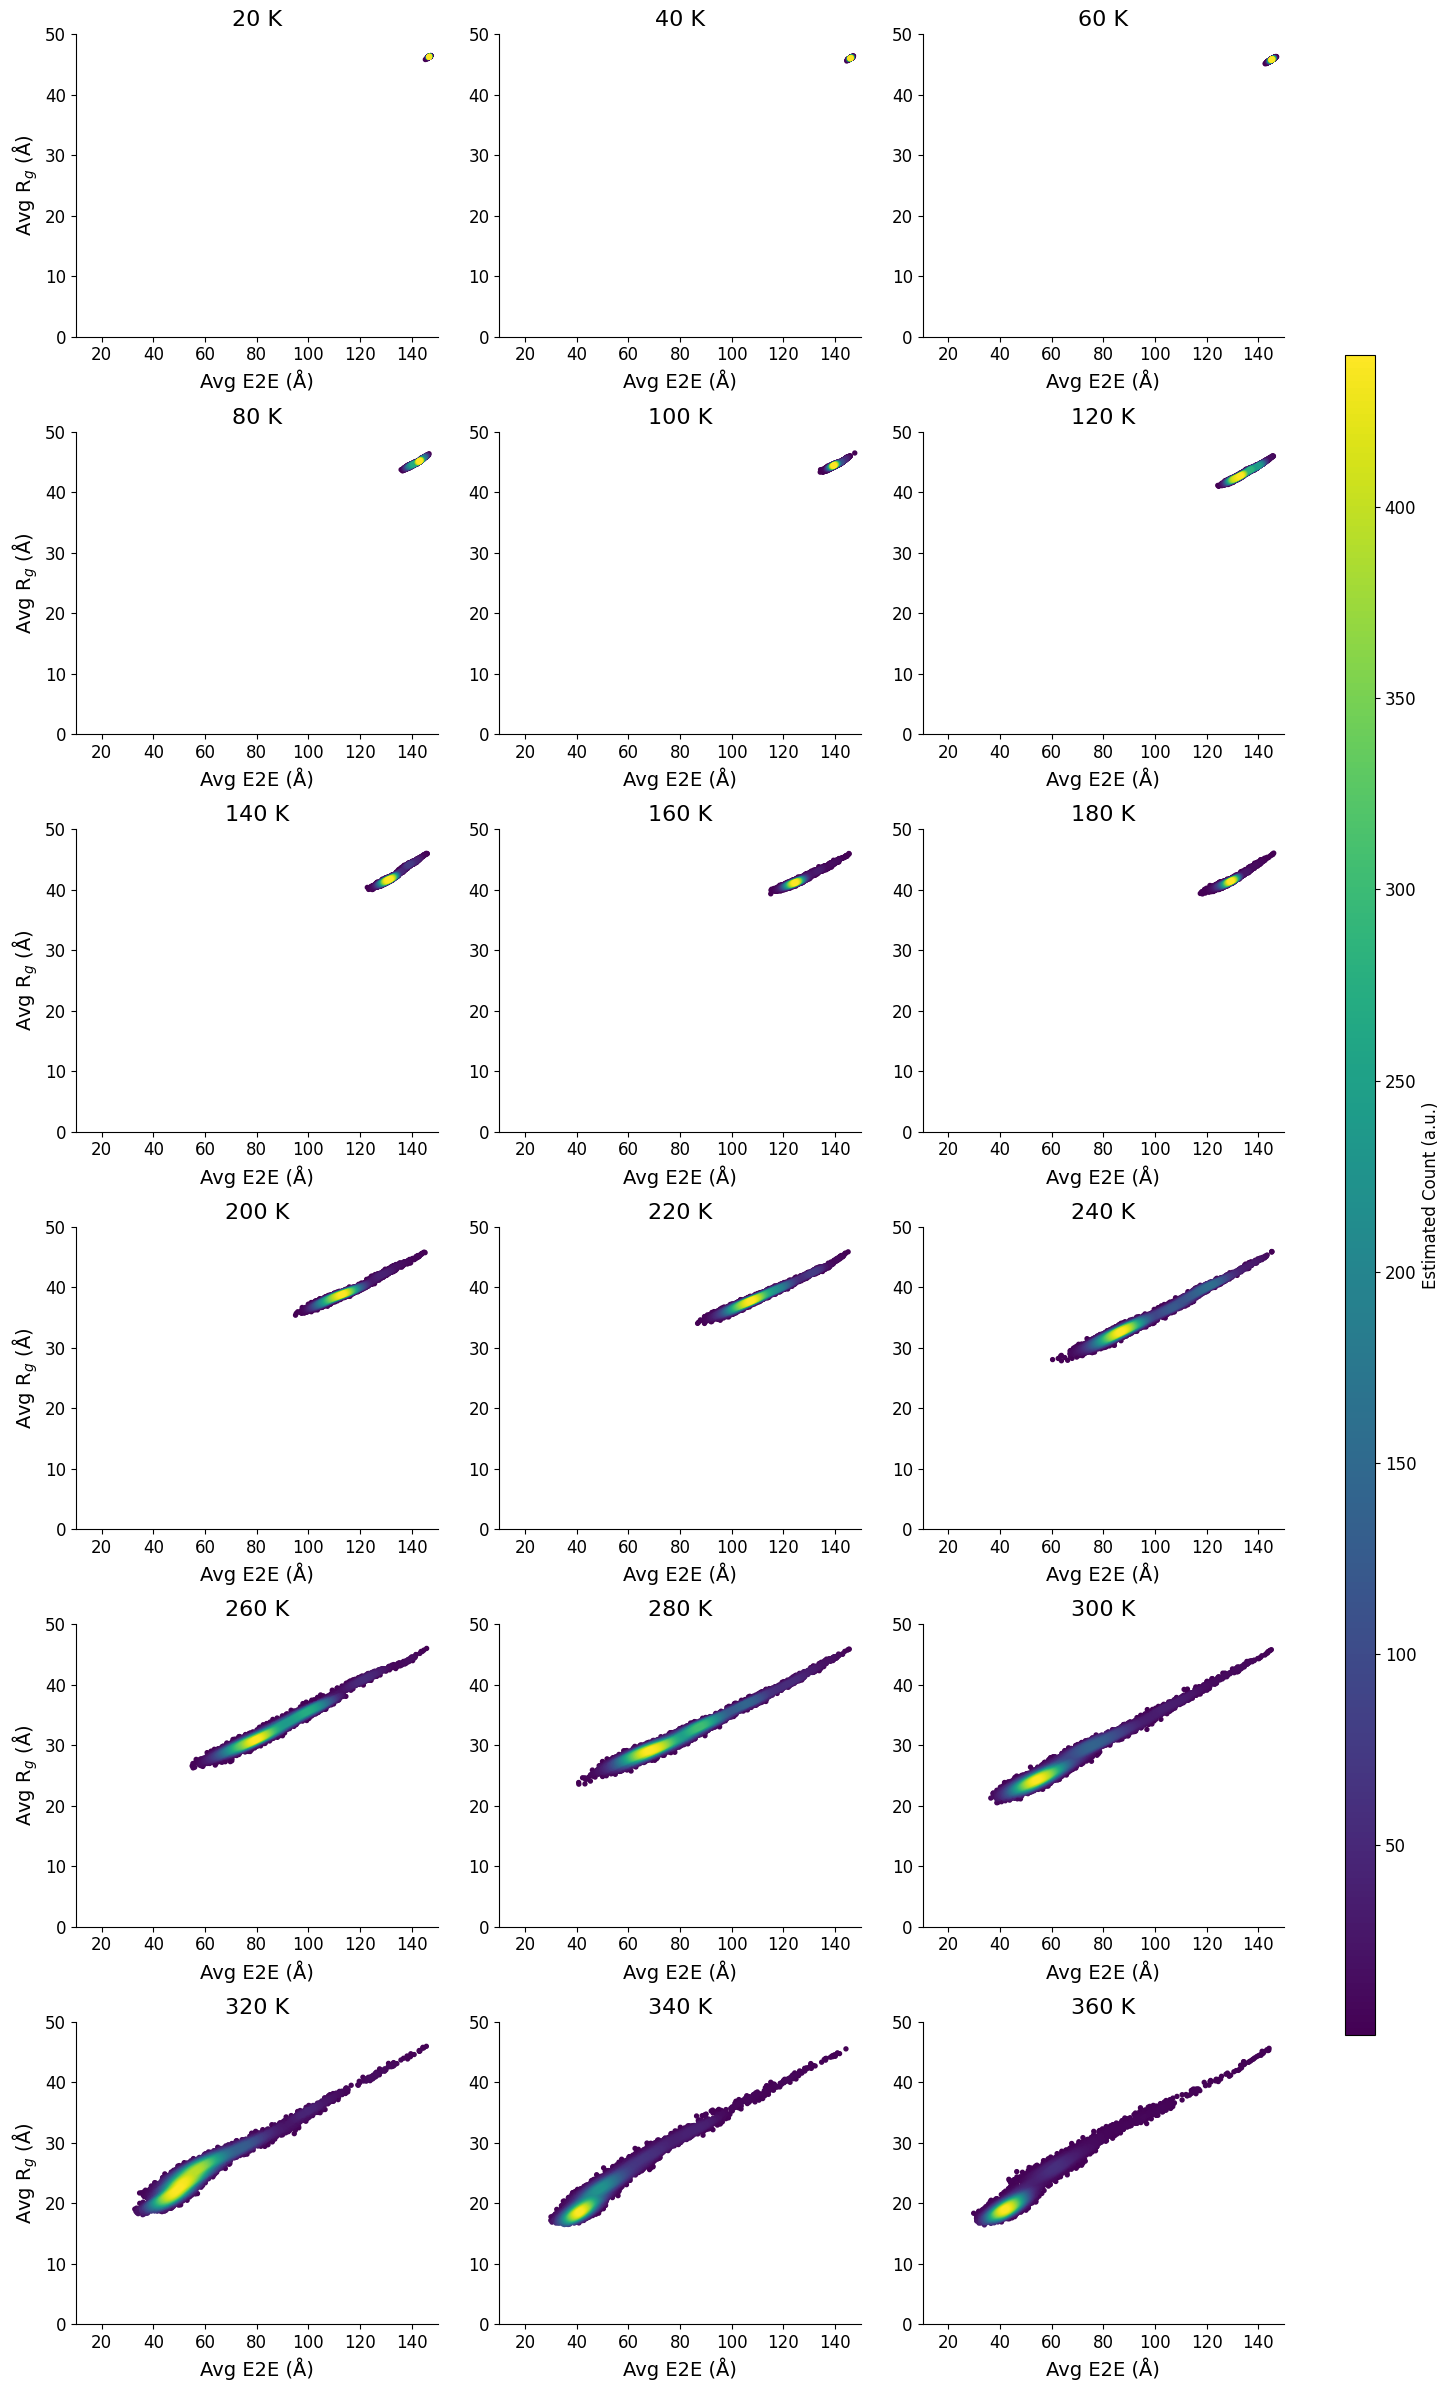

In [13]:
# Scatter of per-frame average E2E vs Rg colored by KDE density, one panel per temperature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import math

# ─── 1) Load your frame‑wise mean CSVs ────────────────────────────────────────
df_rg  = pd.read_csv('POG12_replicas_framewise_meanRg.csv')     # has 'Mean Rg (Å)'
df_e2e = pd.read_csv('POG12_replicas_framewise_meanE2E.csv')    # has 'Mean E2E (Å)'

# ─── 2) Merge on Temperature, Chain, Frame ───────────────────────────────────
df = pd.merge(
    df_rg,
    df_e2e,
    on=['Temperature (K)', 'Chain', 'Frame']
)

# ─── 3) Compute per‑frame average across chains for each temperature ─────────
df_avg = (
    df
      .groupby(['Temperature (K)', 'Frame'], as_index=False)
      [['Mean E2E (Å)', 'Mean Rg (Å)']]
      .mean()
      .rename(columns={
          'Mean E2E (Å)': 'E2E_Å',
          'Mean Rg (Å)' : 'Rg_Å'
      })
)

temps   = sorted(df_avg['Temperature (K)'].unique())
n_temps = len(temps)
n_cols  = 3
n_rows  = math.ceil(n_temps / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4 * n_rows),
                         squeeze=False)

for idx, temp in enumerate(temps):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    sub = df_avg[df_avg['Temperature (K)'] == temp]
    x = sub['E2E_Å'].values
    y = sub['Rg_Å'].values

    # Compute KDE density
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    z   = kde(xy) * len(x)

    # Plot high-density points on top
    order = z.argsort()
    x, y, z = x[order], y[order], z[order]

    sc = ax.scatter(
        x, y,
        c=z,
        s=8,
        cmap='viridis'
    )
    ax.set_title(f'{temp} K', fontsize=16)
    ax.set_xlabel('Avg E2E (Å)', fontsize=14)
    ax.set_ylim(0, 50)
    ax.set_xlim(10, 150)
    if col == 0:
        ax.set_ylabel('Avg R$_g$ (Å)', fontsize=14)
    ax.tick_params(labelsize=12)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)

# Hide unused subplots
total_plots = n_rows * n_cols
for unused in range(len(temps), total_plots):
    r, c = divmod(unused, n_cols)
    axes[r][c].axis('off')

# Shared colorbar
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cax, orientation='vertical')
cbar.set_label('Estimated Count (a.u.)', fontsize=12)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()